<a href="https://colab.research.google.com/github/deshm084/linear-regression-from-scratch-numpy/blob/main/Linear_Regression_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Phase 1: Generate Fake DataWe need data that follows a pattern so we can check if our math works. Let's create data that roughly follows the line y = 2x + 3.

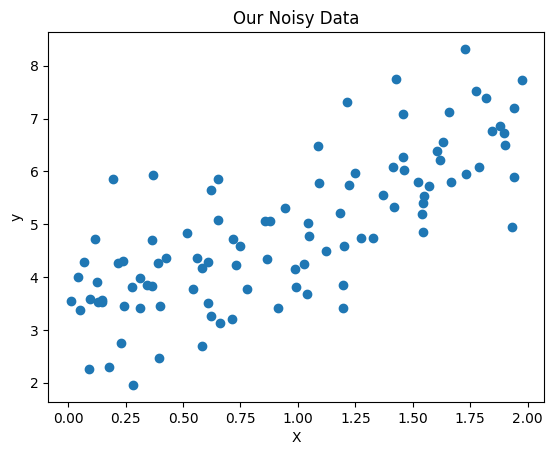

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate synthetic data
np.random.seed(42)
X = 2 * np.random.rand(100, 1) # Random numbers between 0 and 2
y = 3 + 2 * X + np.random.randn(100, 1) # y = 2x + 3 + noise

# 2. Visualize it
plt.scatter(X, y)
plt.title("Our Noisy Data")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

Phase 2: Build the Engine (From Scratch)
Here is the magic. We are writing a class that mimics Scikit-Learn's behavior.

In [ ]:
class LinearRegressionFromScratch:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        # 1. Initialize parameters (weights and bias) to zero
        n_samples, n_features = X.shape
        self.weights = np.zeros((n_features, 1))
        self.bias = 0

        # 2. Gradient Descent Loop
        for _ in range(self.n_iterations):
            # Calculate prediction: y = wx + b
            y_predicted = np.dot(X, self.weights) + self.bias

            # Calculate derivatives (gradients)
            # dw = (2/n) * sum(x * (y_pred - y))
            dw = (1 / n_samples) * np.dot(X.T, (y_predicted - y))
            # db = (2/n) * sum(y_pred - y)
            db = (1 / n_samples) * np.sum(y_predicted - y)

            # Update weights
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

Phase 3: Train and Visualize
Now we test if your math works.

Predicted Weight: 1.77
Predicted Bias: 3.22


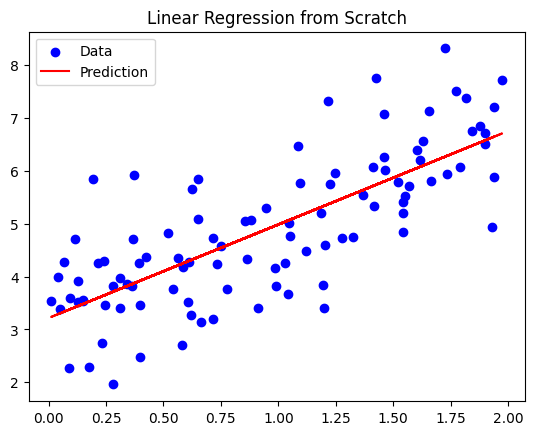

In [ ]:
# 1. Train the model
model = LinearRegressionFromScratch(learning_rate=0.1, n_iterations=1000)
model.fit(X, y)

# 2. Check the parameters
# We expect Weight ≈ 2.0 and Bias ≈ 3.0 (from our data generation step)
print(f"Predicted Weight: {model.weights[0][0]:.2f}")
print(f"Predicted Bias: {model.bias:.2f}")

# 3. Plot the Best Fit Line
y_pred_line = model.predict(X)

plt.scatter(X, y, color='blue', label='Data')
plt.plot(X, y_pred_line, color='red', label='Prediction')
plt.title("Linear Regression from Scratch")
plt.legend()
plt.show()